# **Preparing Dependancies**

In [1]:
!pip install -q diffusers transformers accelerate safetensors

# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [2]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


## **Generate Image**

  0%|          | 0/50 [00:00<?, ?it/s]

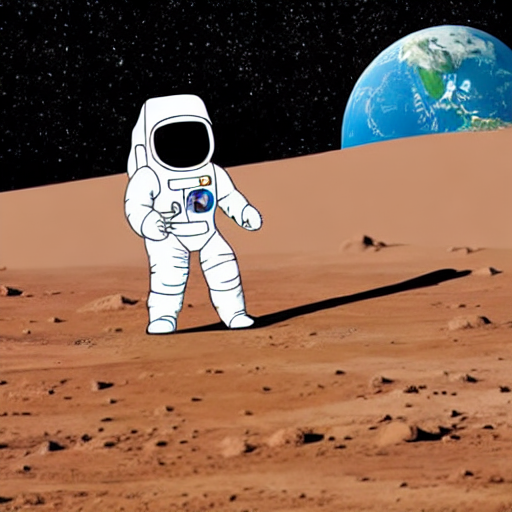

In [3]:
def generate_simple_image(prompt, negative_prompt, seed):
    generator = torch.Generator("cuda").manual_seed(seed)

    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator
    ).images[0]

    return image

prompt = "an astronaut standing on moon surface, earth visible in background, cartoon style"
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"

image_simple = generate_simple_image(prompt, negative_prompt, 222)
image_simple

## **Generate Image with Hyperparameter Configuration**

  0%|          | 0/120 [00:00<?, ?it/s]

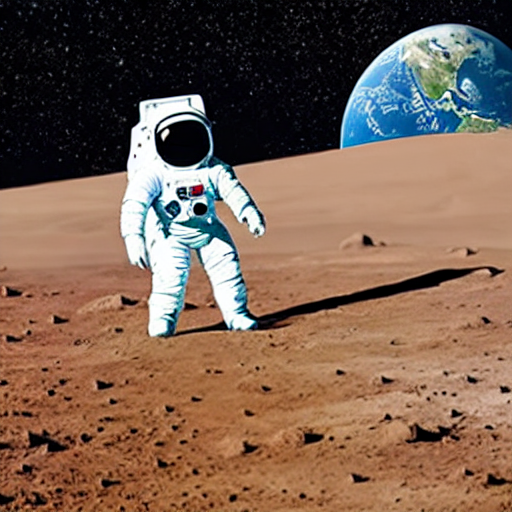

In [4]:
def generate_advanced_image(prompt, negative_prompt, seed, guidance_scale, num_inference_steps):
    generator = torch.Generator("cuda").manual_seed(seed)

    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps
    ).images[0]

    return image

image_advanced = generate_advanced_image(prompt, negative_prompt, 222, 10, 120)
image_advanced

## **Guidance Scale Comparison**

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

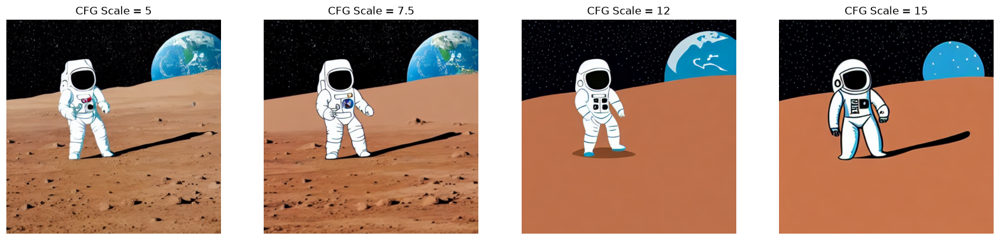

In [5]:
import matplotlib.pyplot as plt
guidance_scales = [5, 7.5, 12, 15]
images = []

for scale in guidance_scales:
    generator = torch.Generator("cuda").manual_seed(222)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=scale,
        generator=generator
    ).images[0]
    images.append(img)

plt.figure(figsize=(20, 5))
for i, img in enumerate(images):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(f"CFG Scale = {guidance_scales[i]}")
    plt.axis("off")
plt.show()

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
Dengan scale yang kecil (5), gambar lebih detail dan lebih realistis. Dataran bulan bertekstur seperti pasir asli dan batu-batu kecil, Bumi juga terlihat lebih realistis.

*   **Gambar dengan "Scale" Tinggi:**   
Semakin tinggi scalenya, 12 dan 15, detailnya semakin berkurang. Batu-batu pada bulan hilang, tekstur tanah jadi datar, Bumi mengecil, warna makin pudar dan terlihat sangat sintesis. Semua elemen pada prompt tetap ada, tapi model menjadi terlalu sintesis dan membuang detail yang tidak disebut eksplisit.

## **Inference Steps Comparison**

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

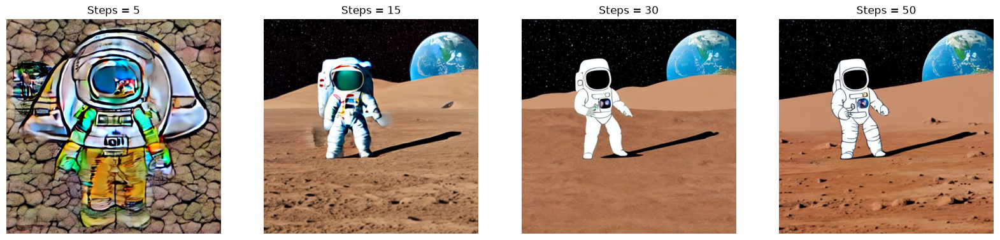

In [6]:
steps_list = [5, 15, 30, 50]
images = []

for steps in steps_list:
    generator = torch.Generator("cuda").manual_seed(222)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        generator=generator
    ).images[0]
    images.append(img)

plt.figure(figsize=(20, 5))
for i, img in enumerate(images):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Steps = {steps_list[i]}")
    plt.axis("off")
plt.show()

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
Pada 5 step (rendah) gambar tidak berbentuk dan sangat abstrak, wajah dan tubuh abstrak, permukaan berbentuk tekstur retak acak karena denoising belum selesai. Pada 15 step, gambar mulai berbentuk seperti promptnya tetapi masih banyak yang abstrak: astronot sangat kecil, muncul objek putih besar menimpa bumi, dan ada teks tidak jelas di langit.
*   **Gambar dengan "Step" Tinggi:**  
Pada step 30 dan 50, hasilnya berbentuk dan lebih bagus, sesuai dengan promptnya. Gambar astronot terbentuk dengan detail helm dan sarung tangan, langit  berbintang, tanah juga halus bertekstur, abstrak hilang. Perbedaan step 30 ke 50 sudah kecil yang artinya hasil mulai konvergen.

## **Batch Inference from One Prompt**

  0%|          | 0/50 [00:00<?, ?it/s]

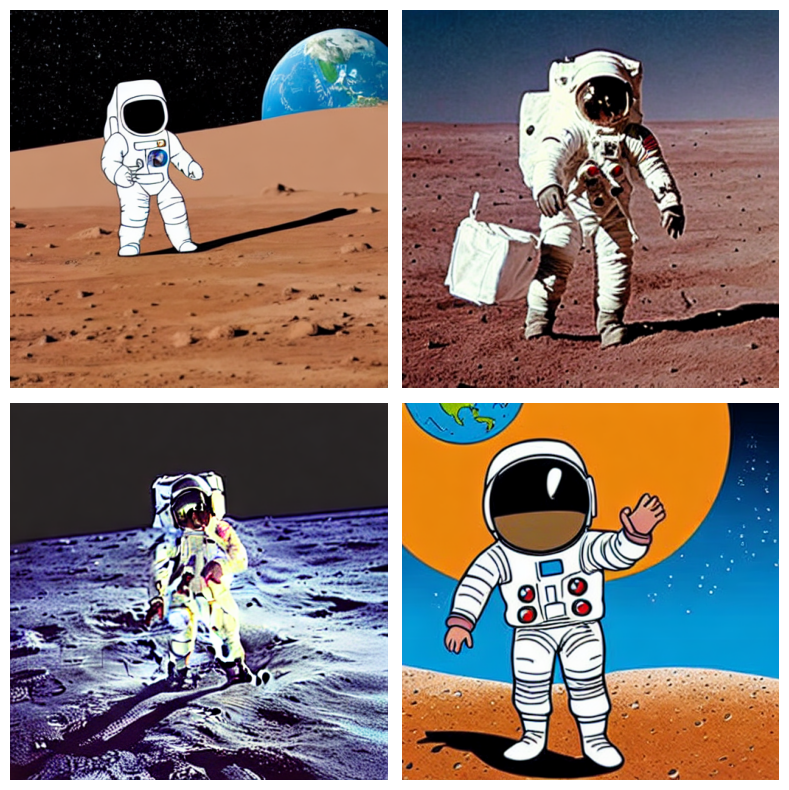

In [7]:
generator = torch.Generator("cuda").manual_seed(222)

images_batch = pipe(
    prompt=[prompt] * 4,
    negative_prompt=[negative_prompt] * 4,
    generator=generator
).images

plt.figure(figsize=(8, 8))
for i, img in enumerate(images_batch):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

## **Load Scheduler**

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

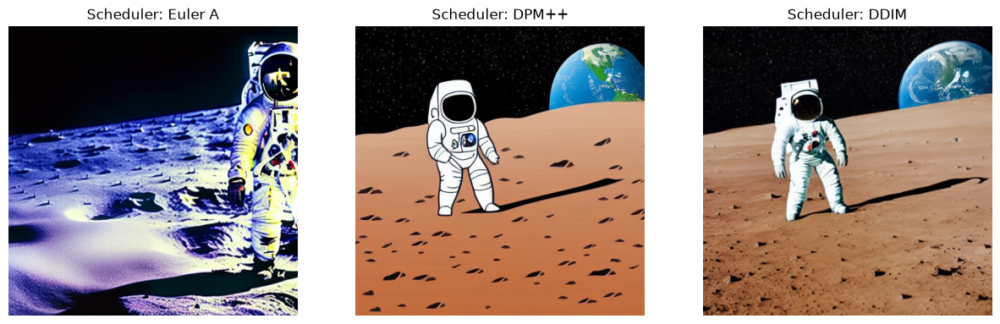

In [8]:
from diffusers import EulerAncestralDiscreteScheduler, DPMSolverMultistepScheduler, DDIMScheduler

def load_scheduler(pipe, scheduler_name):
    if scheduler_name == "Euler A":
        pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler_name == "DPM++":
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    elif scheduler_name == "DDIM":
        pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

    return pipe

scheduler_names = ["Euler A", "DPM++", "DDIM"]
images = []

for name in scheduler_names:
    pipe = load_scheduler(pipe, name)
    generator = torch.Generator("cuda").manual_seed(222)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=30,
        generator=generator
    ).images[0]
    images.append(img)

plt.figure(figsize=(15, 5))
for i, img in enumerate(images):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Scheduler: {scheduler_names[i]}")
    plt.axis("off")
plt.show()

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
Hasil sangat realistis (tidak kartun), terdapat pantulan di visor, efek shining di pasirnya, dan bayangan-bayangan. Warnanya paling kontras.
*   **Gambar dengan "DPM++ Scheduler":**  
Paling bersih dan paling sesuai dengan prompt. Gambar terlihat kartun, outline rapi, tanah bertekstur, Bumi terlihat jelas dengan pulau"nya. Komposisinya seimbang.
*   **Gambar dengan "DDIM Scheduler":**  
Gambar mirip DPM++ tetapi detail gambarnya (astronot, dataran bulan, dan bumi) menjadi lebih detail dan semi-kartun dan realistik

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

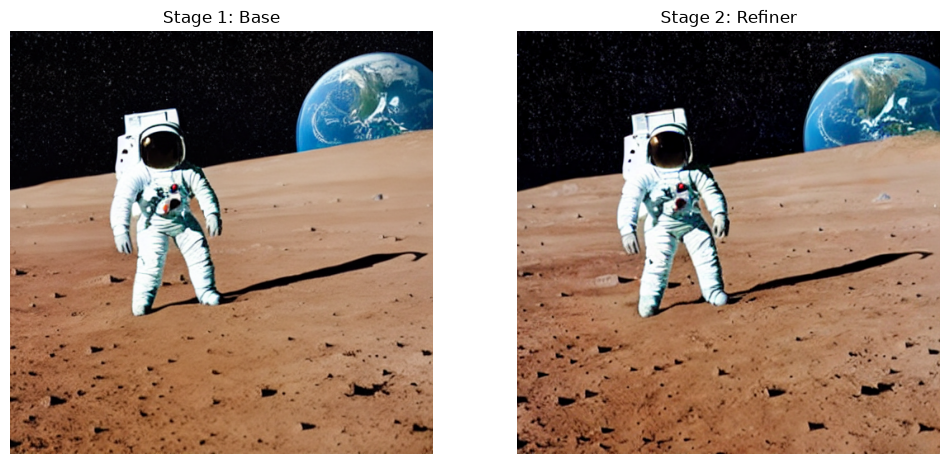

In [9]:
from diffusers import StableDiffusionImg2ImgPipeline

img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    text_encoder=pipe.text_encoder,
    vae=pipe.vae,
    unet=pipe.unet,
    tokenizer=pipe.tokenizer,
    safety_checker=None,
    torch_dtype=torch.float16
).to("cuda")

# Stage 1: Base
generator = torch.Generator("cuda").manual_seed(222)
image_base = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator
).images[0]

# Stage 2: Refiner
generator = torch.Generator("cuda").manual_seed(222)
image_refined = img2img_pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=image_base,
    strength=0.2,
    guidance_scale=7.5,
    generator=generator
).images[0]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_base)
plt.title("Stage 1: Base")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_refined)
plt.title("Stage 2: Refiner")
plt.axis("off")
plt.show()

## **Inpainting**

### **Load Model Inpainting**

In [10]:
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image, ImageDraw

inpaint_model_id = "runwayml/stable-diffusion-inpainting"

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    inpaint_model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe_inpaint = pipe_inpaint.to("cuda")
pipe_inpaint.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\K E N\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\K E N\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\K E N\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\K E N\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


### **Manual Masking**

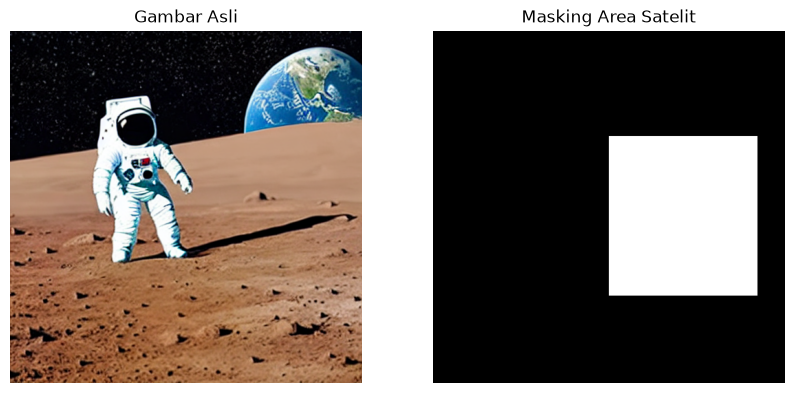

In [11]:
init_image = image_advanced.resize((512, 512))

mask = Image.new("L", init_image.size, 0)
draw = ImageDraw.Draw(mask)

width, height = init_image.size

# Koordinat mask
left = width * 0.50
top = height * 0.30
right = width * 0.92
bottom = height * 0.75

# Kotak putih di area satelit
draw.rectangle((left, top, right, bottom), fill=255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Masking Area Satelit")
plt.axis("off")
plt.show()

### **Generate**

  0%|          | 0/120 [00:00<?, ?it/s]

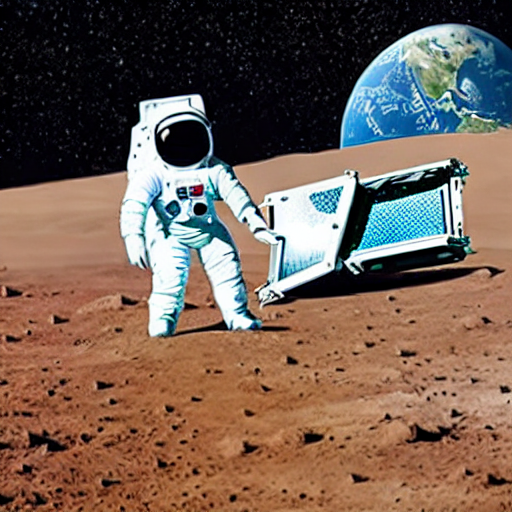

In [22]:
prompt_satellite = (
    "a damaged broken satellite crashed on the moon surface, "
    "lunar surface with craters, metallic debris, broken panels, exposed mechanical parts, "
    "multi-legged landing gear, "
    "highly detailed mechanical structure, sharp focus, "
    "realistic scale, cinematic lighting"
)
negative_prompt_satellite = "blurry, low quality, distorted, messy, person, human, astronaut, intact, clean, symmetrical"
seed = 9

generator = torch.Generator("cuda").manual_seed(seed)

image_inpainting = pipe_inpaint(
    prompt=prompt_satellite,
    negative_prompt=negative_prompt_satellite,
    image=init_image,
    mask_image=mask,
    guidance_scale=12,
    num_inference_steps=120,
    strength=1,
    generator=generator
).images[0]

image_inpainting

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

In [13]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

seg_processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
seg_model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

### **Masking with Segmentation Model**

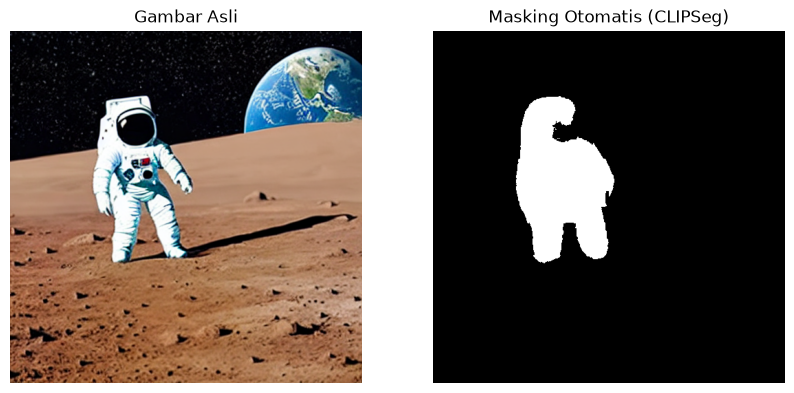

In [14]:
seg_prompt = "white space suit"

inputs = seg_processor(text=[seg_prompt], images=[init_image], padding=True, return_tensors="pt")

with torch.no_grad():
    outputs = seg_model(**inputs)

preds = torch.sigmoid(outputs.logits).squeeze()
mask_array = (preds.numpy() * 255).astype("uint8")

auto_mask = Image.fromarray(mask_array).resize(init_image.size)
auto_mask = auto_mask.point(lambda p: 255 if p > 100 else 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(auto_mask, cmap="gray")
plt.title("Masking Otomatis (CLIPSeg)")
plt.axis("off")
plt.show()

### **Generate**

  0%|          | 0/27 [00:00<?, ?it/s]

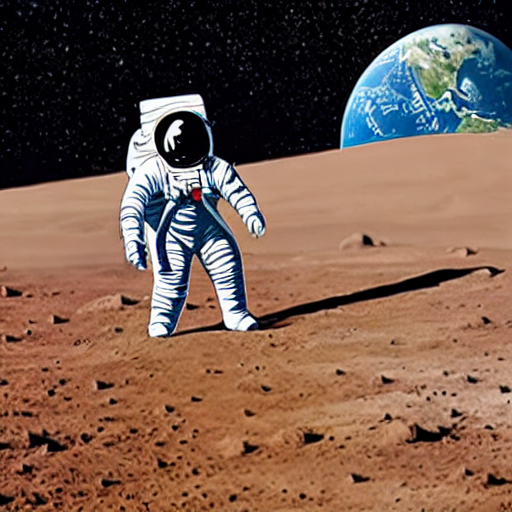

In [15]:
prompt_auto = "an astronaut wearing a bright orange space suit, cartoon illustration, digital art"

generator = torch.Generator("cuda").manual_seed(9)

image_auto_inpaint = pipe_inpaint(
    prompt=prompt_auto,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=auto_mask,
    guidance_scale=7.5,
    num_inference_steps=30,
    strength=0.9,
    generator=generator
).images[0]

image_auto_inpaint

## **Outpainting**

### **Prepare the Canvas**

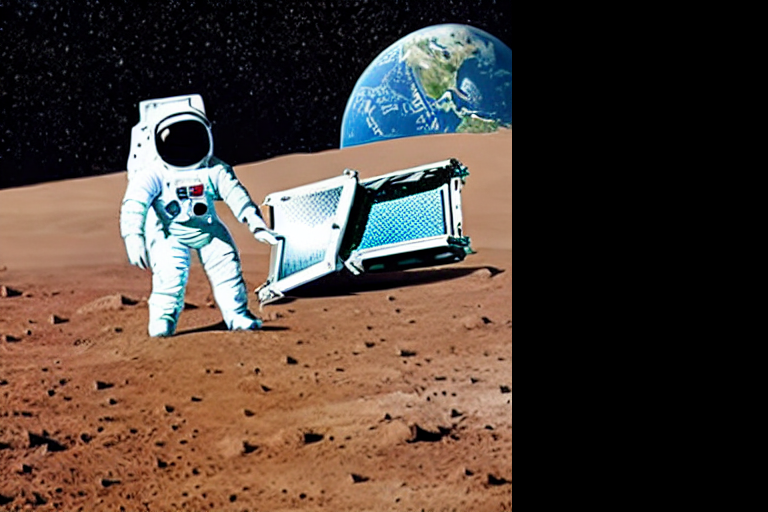

In [16]:
old_width, old_height = image_inpainting.size
new_width = old_width + 256

outpaint_image = Image.new("RGB", (new_width, old_height))
outpaint_image.paste(image_inpainting, (0, 0))

outpaint_mask = Image.new("L", (new_width, old_height), 255)

original_area_mask = Image.new("L", (old_width, old_height), 0)
outpaint_mask.paste(original_area_mask, (0, 0))

outpaint_image

### **Generate**

Sedang memperluas kanvas...


  0%|          | 0/50 [00:00<?, ?it/s]

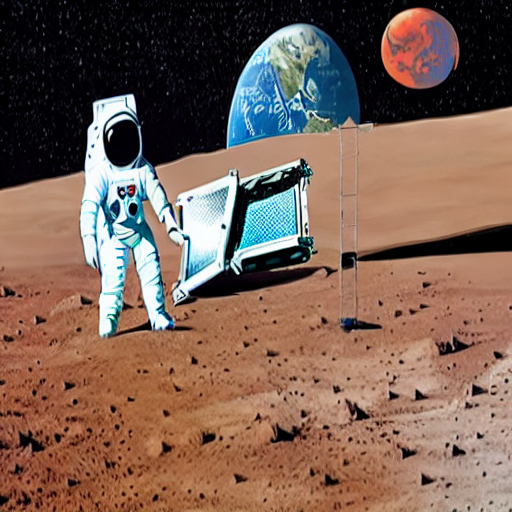

In [17]:
prompt_outpaint = "an astronaut on the moon surface with a broken satellite, brown red lunar soil, black starry sky, planet earth in the sky, cartoon illustration, digital art"

generator = torch.Generator("cuda").manual_seed(555)

print("Sedang memperluas kanvas...")

image_outpainting = pipe_inpaint(
    prompt=prompt_outpaint,
    negative_prompt=negative_prompt,
    image=outpaint_image,
    mask_image=outpaint_mask,
    guidance_scale=7.5,
    num_inference_steps=50,
    strength=1.0,
    generator=generator
).images[0]

image_outpainting

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

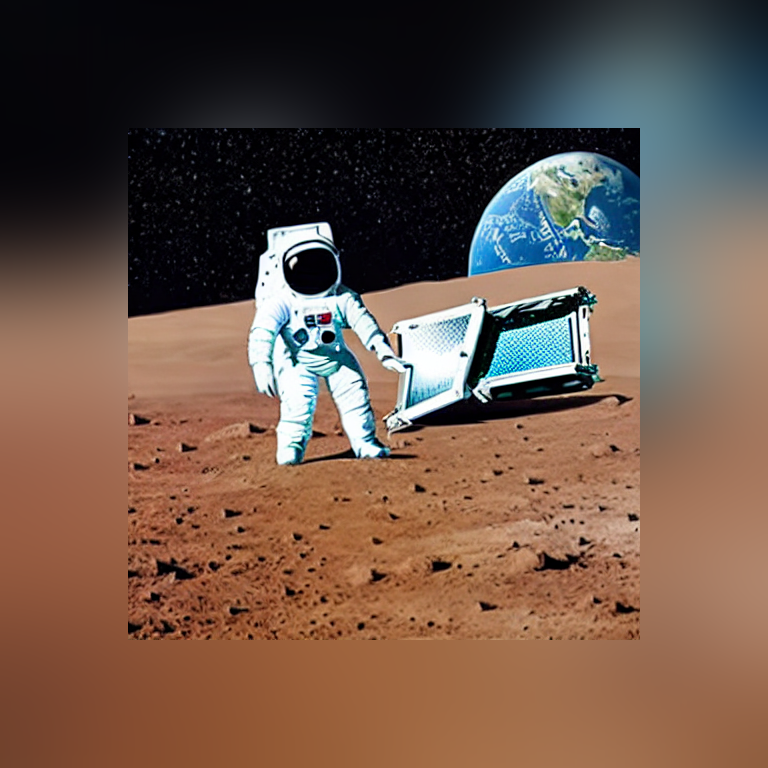

In [18]:
from PIL import ImageFilter

expand_pixels = 128

old_width, old_height = image_inpainting.size
new_width = old_width + expand_pixels * 2
new_height = old_height + expand_pixels * 2

# Background blur agar tidak ada tepi tegas
bg = image_inpainting.resize((new_width, new_height), resample=Image.BICUBIC)
bg = bg.filter(ImageFilter.GaussianBlur(radius=50))

zoom_image = bg.copy()
zoom_image.paste(image_inpainting, (expand_pixels, expand_pixels))

zoom_mask = Image.new("L", (new_width, new_height), 255)

original_area_mask = Image.new("L", (old_width, old_height), 0)
zoom_mask.paste(original_area_mask, (expand_pixels, expand_pixels))

zoom_image

### **Generate**

Sedang melakukan zoom out...


  0%|          | 0/50 [00:00<?, ?it/s]

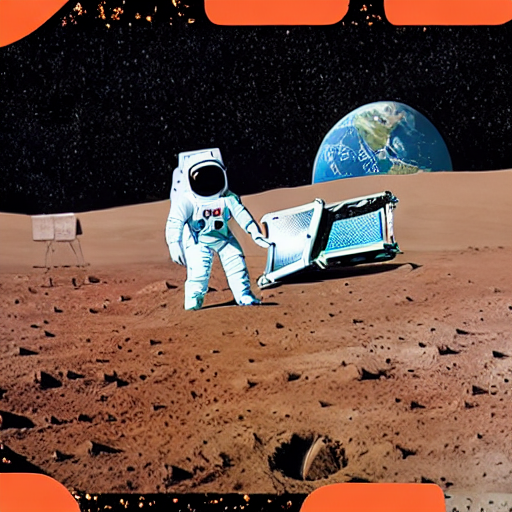

In [19]:
prompt_zoom = "wide angle view of an astronaut on the moon surface with a broken satellite, brown red lunar soil, black starry sky, planet earth in the sky, cartoon illustration, digital art"

generator = torch.Generator("cuda").manual_seed(555)

print("Sedang melakukan zoom out...")

image_zoomout = pipe_inpaint(
    prompt=prompt_zoom,
    negative_prompt=negative_prompt,
    image=zoom_image,
    mask_image=zoom_mask,
    guidance_scale=7.5,
    num_inference_steps=50,
    strength=1.0, # Strength 1.0 wajib untuk outpainting
    generator=generator
).images[0]

image_zoomout

In [20]:
pip list

Package                   Version
------------------------- ------------
absl-py                   2.5.0
accelerate                1.14.0
aiohappyeyeballs          2.7.1
aiohttp                   3.14.1
aiosignal                 1.4.0
altair                    6.2.2
annotated-doc             0.0.4
anyio                     4.14.2
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.2
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
blinker                   1.9.0
boto3                     1.43.48
botocore                  1.43.48
cachetools                7.1.4
certifi                   2026.6.17
cffi                      2.1.0
charset-normalizer        3.4.9
click                     8.4.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler         